# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [36]:
# Import necessary libraries
import os
import random
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import re
import tensorflow as tf

from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.preprocessing.sequence import pad_sequences


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
data_dir = pathlib.Path(
    "/content/drive/MyDrive/WasteManagement/RealWaste"
)

if not data_dir.exists():
    raise FileNotFoundError("RealWaste folder not found!")

print("Dataset location:", data_dir.resolve())

Dataset location: /content/drive/MyDrive/WasteManagement/RealWaste


In [12]:
#List waste categories


class_folders = sorted([
    folder for folder in data_dir.iterdir()
    if folder.is_dir()
])


class_names = [folder.name for folder in class_folders]


print("Number of waste categories:", len(class_names))

print("\nWaste categories:")
for class_name in class_names:
    print(class_name)

Number of waste categories: 9

Waste categories:
Cardboard
Food Organics
Glass
Metal
Miscellaneous Trash
Paper
Plastic
Textile Trash
Vegetation


In [13]:
# Count images in each category

image_extensions = {".jpg", ".jpeg", ".png"}

class_counts = {}

for folder in class_folders:

    images = [
        file for file in folder.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    class_counts[folder.name] = len(images)

print(class_counts)

{'Cardboard': 461, 'Food Organics': 411, 'Glass': 420, 'Metal': 790, 'Miscellaneous Trash': 495, 'Paper': 500, 'Plastic': 921, 'Textile Trash': 318, 'Vegetation': 436}


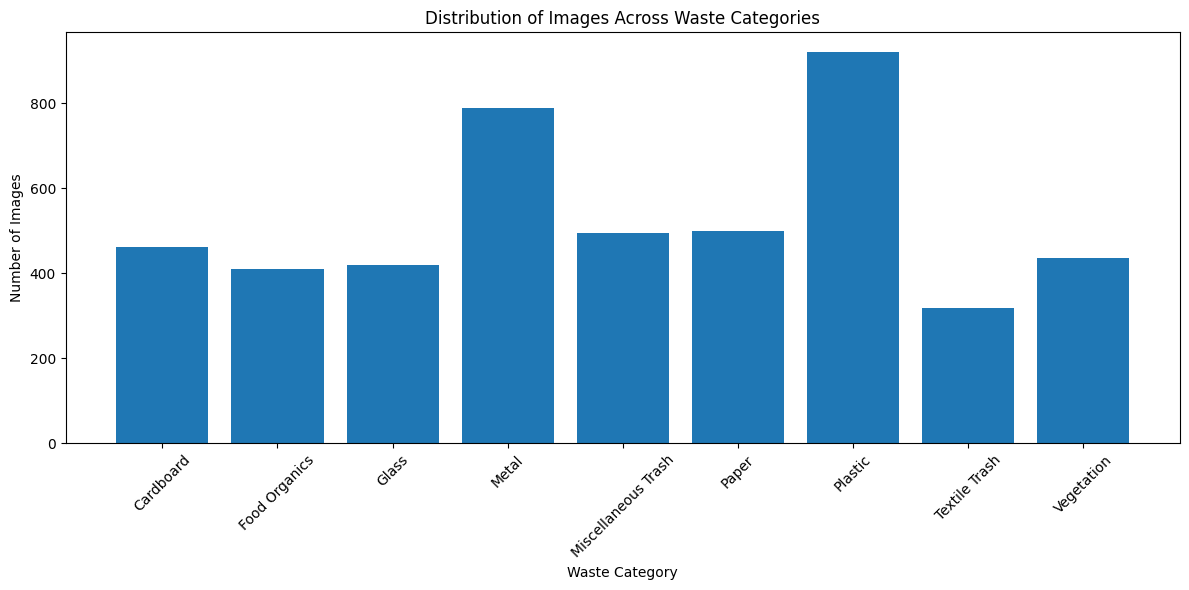

In [14]:
# Visualize the class distribution
plt.figure(figsize=(12, 6))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.title("Distribution of Images Across Waste Categories")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

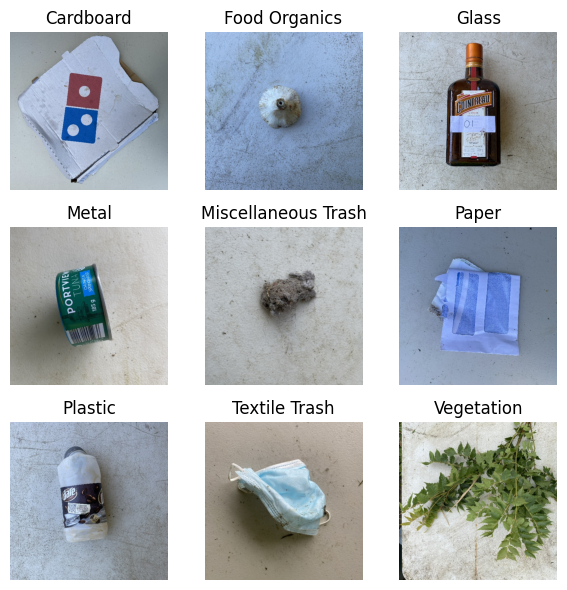

In [15]:
# Visulaize images

plt.figure(figsize=(6, 6))

for i, folder in enumerate(class_folders):

    # Get image files in the current category
    images = [
        file for file in folder.iterdir()
        if file.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]

    # Select one random image
    image_path = random.choice(images)

    # Open the image
    img = Image.open(image_path)

    # Display it
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(folder.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Check image dimensions
image_sizes = []

for folder in class_folders:

    images = [
        file for file in folder.iterdir()
        if file.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]

    for image_path in images:
        with Image.open(image_path) as img:
            image_sizes.append(img.size)

# Convert to DataFrame
sizes_df = pd.DataFrame(
    image_sizes,
    columns=["Width", "Height"]
)

print("Image dimensions summary:")
display(sizes_df.describe())

print("\nNumber of unique image dimensions:",
      sizes_df.drop_duplicates().shape[0])

Image dimensions summary:


,Width,Height
count,4752.0,4752.0
mean,524.0,524.0
std,0.0,0.0
min,524.0,524.0
25%,524.0,524.0
50%,524.0,524.0
75%,524.0,524.0
max,524.0,524.0



Number of unique image dimensions: 1


The dataset has 4752 images distributed across 9 categiries. The dataset is imbalance as the highest number of images (921) and Textile Trash having the lowest (318).
Image dimension analysis revealed that all 4,752 images have consistent dimensions of 524 × 524 pixels.
Also, since the images are square, resizing them to 224 × 224 pixels will preserve their aspect ratio.

### **Waste descriptions dataset exploration**

In [17]:
#Load the csv file from the drive
text_data_path = (
    "/content/drive/MyDrive/WasteManagement/"
    "waste_descriptions.csv"
)

text_df = pd.read_csv(text_data_path)

text_df.head()


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...


In [22]:
text_df.shape

(5000, 5)

In [23]:
text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB


In [24]:
#check missing values
text_df.isnull().sum()

,0
description,0
category,0
disposal_instruction,0
common_confusion,2504
material_composition,0


In [25]:
#Check for duplicates
text_df.duplicated().sum()

np.int64(7)

In [26]:
# Display duplicate records
duplicates = text_df[text_df.duplicated(keep=False)]

print("Number of duplicate records:", len(duplicates))

display(duplicates)

Number of duplicate records: 14


,description,category,disposal_instruction,common_confusion,material_composition
317,CD case,Plastic,"If unmarked or non-recyclable plastic, place i...",Plastic bags often can not go in general recyc...,Polymer materials derived from petrochemicals ...
702,clamshell packaging,Plastic,Plastic bags can be returned to supermarket co...,Plastic bags often can not go in general recyc...,Polymer materials derived from petrochemicals ...
711,water bottle,Plastic,Remove labels if possible.,Plastic bags often can not go in general recyc...,Polymer materials derived from petrochemicals ...
895,full patterned tree limbs,Vegetation,Check if your area has seasonal leaf collection.,Invasive species may require special disposal....,Plant matter composed primarily of cellulose a...
1072,clamshell packaging,Plastic,Plastic bags can be returned to supermarket co...,Plastic bags often can not go in general recyc...,Polymer materials derived from petrochemicals ...
1091,wet pine needles,Vegetation,Consider home composting for small amounts.,Invasive species may require special disposal....,Plant matter composed primarily of cellulose a...
1678,beer bottle,Glass,"Place in glass recycling bin, sorted by color ...",NaN,"Silica-based material, may contain additives f..."
2171,water bottle,Plastic,Remove labels if possible.,Plastic bags often can not go in general recyc...,Polymer materials derived from petrochemicals ...
2425,glass tabletop,Glass,Non-container glass may require special disposal.,NaN,"Silica-based material, may contain additives f..."
2975,glass tabletop,Glass,Non-container glass may require special disposal.,NaN,"Silica-based material, may contain additives f..."


In [27]:
#drop duplicates
text_df = text_df.drop_duplicates()


In [28]:
#Check for duplicates
text_df.duplicated().sum()

np.int64(0)

In [31]:
#category distribution
category_counts = text_df["category"].value_counts()

print(category_counts)

category
Vegetation             598
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                566
Glass                  549
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


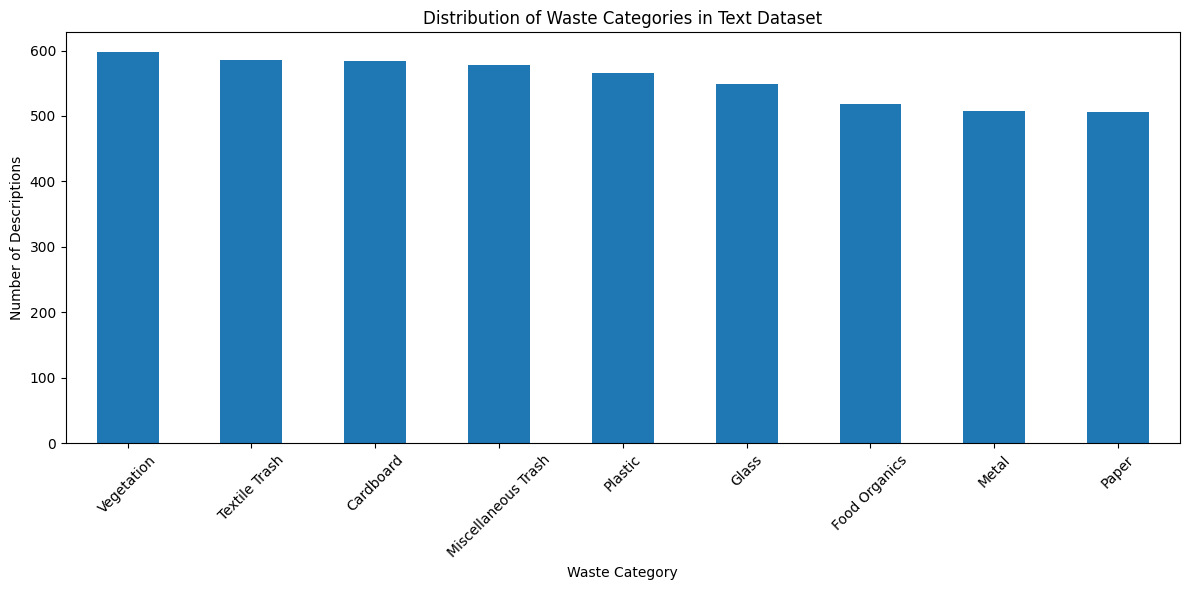

In [32]:
#Visualize
plt.figure(figsize=(12, 6))

category_counts.plot(kind="bar")

plt.xlabel("Waste Category")
plt.ylabel("Number of Descriptions")
plt.title("Distribution of Waste Categories in Text Dataset")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
#Inspect the description lengths

text_df["description_length"] = (
    text_df["description"].apply(lambda x: len(x.split()))
)

print(text_df["description_length"].describe())

count    4993.000000
mean        4.857400
std         1.548137
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: description_length, dtype: float64


In [34]:
# Display 15 random descriptions and their categories
display(
    text_df[["description", "category"]]
    .sample(15, random_state=42)
)

,description,category
3172,new small perfume bottle,Glass
3103,used small yellow Homemade takeout container,Plastic
624,ripped composite Generic wood piece,Miscellaneous Trash
4041,soiled Designer perfume bottle,Glass
969,large brown Designer silk tie containing residue,Textile Trash
803,dirty personal silver Bulk potted plant,Vegetation
3912,dry floral cotton towel,Textile Trash
3634,broken striped Homemade paper plate with label...,Paper
1433,massive patterned biodegradable ceramic mug,Miscellaneous Trash
3682,intact small striped styrofoam,Miscellaneous Trash


In [35]:
# Display five descriptions for each category

for category in sorted(text_df["category"].unique()):

    print(f"\nCATEGORY: {category}")
    print("-" * 50)

    descriptions = text_df[
        text_df["category"] == category
    ]["description"].head(5)

    for description in descriptions:
        print("-", description)


CATEGORY: Cardboard
--------------------------------------------------
- Designer egg carton
- stained red cardboard sleeve with label attached
- new regular-sized purple cardboard tray
- wet small Bulk shoe box
- broken orange cardboard mailer

CATEGORY: Food Organics
--------------------------------------------------
- large Supermarket vegetable waste with food residue
- empty fun-sized purple apple core
- wet compact orange peel with label attached
- soiled enormous gold Premium nut shells containing residue
- torn large patterned coffee grounds

CATEGORY: Glass
--------------------------------------------------
- folded glass bottle leaking
- broken glass container
- clean red wine bottle with food residue
- folded red glass pitcher
- floral light bulb containing residue

CATEGORY: Metal
--------------------------------------------------
- wrinkled metal cutlery with food residue
- partial large purple metal pipe
- used regular-sized striped bottle cap with contents
- broken mass

In [37]:
# Text cleaning function

def clean_text(text):

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [39]:
#apply the function
text_df["clean_description"] = (
    text_df["description"].apply(clean_text)
)

display(
    text_df[
        ["description", "clean_description"]
    ].head(10)
)

,description,clean_description
0,soiled silver tablecloth,soiled silver tablecloth
1,folded glass bottle leaking,folded glass bottle leaking
2,large Supermarket vegetable waste with food re...,large supermarket vegetable waste with food re...
3,intact floral carpet piece,intact floral carpet piece
4,empty fun-sized purple apple core,empty fun sized purple apple core
5,wrinkled pink takeout container with product r...,wrinkled pink takeout container with product r...
6,broken glass container,broken glass container
7,clean red grass clippings,clean red grass clippings
8,Designer egg carton,designer egg carton
9,wrinkled metal cutlery with food residue,wrinkled metal cutlery with food residue


In [41]:
#Keras text vectorization pipeline
# Define vocabulary size
MAX_TOKENS = 1000

# Define sequence length
MAX_LENGTH = 10

# Create vectorization layer
vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LENGTH
)

vectorizer.adapt(
    text_df["clean_description"].values
)

In [18]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here

### 1.2 Explore Text Datasets

In [19]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here

In [20]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Your code here

### 1.3 Create Data Pipelines

In [21]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 0
Class names: []
Total images found: 0


FileNotFoundError: [Errno 2] No such file or directory: 'RealWaste'

In [ ]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

# Your code here

In [ ]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here

## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [ ]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here

### 2.2 Implement CNN Model with Transfer Learning

In [ ]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here

### 2.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 2.4 Fine-tune the Model

In [ ]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [ ]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

### 3.2 Implement Text Classification Model

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

### 3.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.